In [110]:
import pandas as pd
import numpy as np
import sqlite3

# Data visualization library
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

**_Load the Dataset_**

In [111]:
df=pd.read_csv('SuperMarket Analysis.csv')

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


**_Data Cleaning_**

The dataset will be checked for missing values, duplicate records, and appropriate data types before analysis.

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

Check for NULL values

In [113]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Check for duplicate rows

In [114]:
df.duplicated().sum()

0

In [115]:
df['Date'].dtype

dtype('O')

In [116]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [117]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day_name()

df['Time'] = pd.to_datetime(df['Time'], format="%I:%M:%S %p")
df['Hour'] = df['Time'].dt.hour

**_Create SQLite Database_**

The cleaned dataset will be stored in an SQLite database so that SQL queries can be used for analysis.

In [118]:
conn = sqlite3.connect('supermarket.db')

sales = pd.read_csv('SuperMarket Analysis.csv')

df.to_sql('sales', conn, if_exists='replace', index=False)

1000

In [119]:
query = """
SELECT *
FROM sales
LIMIT 5;
"""

pd.read_sql(query, conn)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,...,Time,Payment,cogs,gross margin percentage,gross income,Rating,Year,Month,Day,Hour
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,2019,January,Saturday,13
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,2019,March,Friday,10
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,...,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,2019,March,Sunday,13
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,...,1900-01-01 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,2019,January,Sunday,20
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,...,1900-01-01 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,2019,February,Friday,10


Now that the dataset is stored in SQLite, we can answer business questions using SQL.

**_Overall Business Performance_**

In this section, we will address key business questions to gain a comprehensive understanding of the supermarket’s overall performance.

**1.- Which hour have more sales?**

To determine which time of day generates the highest sales, we will not only look at the total number of sales, while this is an important metric, it does not provide the full picture. We will also analyze total revenue to better understand the data and calculate the average revenue generated per hour.

In [120]:
query = """
SELECT
    Hour,
    COUNT(*) AS total_sales,
    ROUND(SUM(Sales), 2) AS total_revenue,
    ROUND(AVG(Sales), 2) AS average_revenue
FROM sales
GROUP BY Hour
ORDER BY total_revenue DESC;
"""

hour_performance = pd.read_sql(query, conn)

hour_performance

,Hour,total_sales,total_revenue,average_revenue
0,19,113,39699.51,351.32
1,13,103,34723.23,337.12
2,10,101,31421.48,311.10
3,15,102,31179.51,305.68
4,14,83,30828.40,371.43
5,11,90,30377.33,337.53
6,12,89,26065.88,292.88
7,18,93,26030.34,279.90
8,16,77,25226.32,327.61
9,17,74,24445.22,330.34


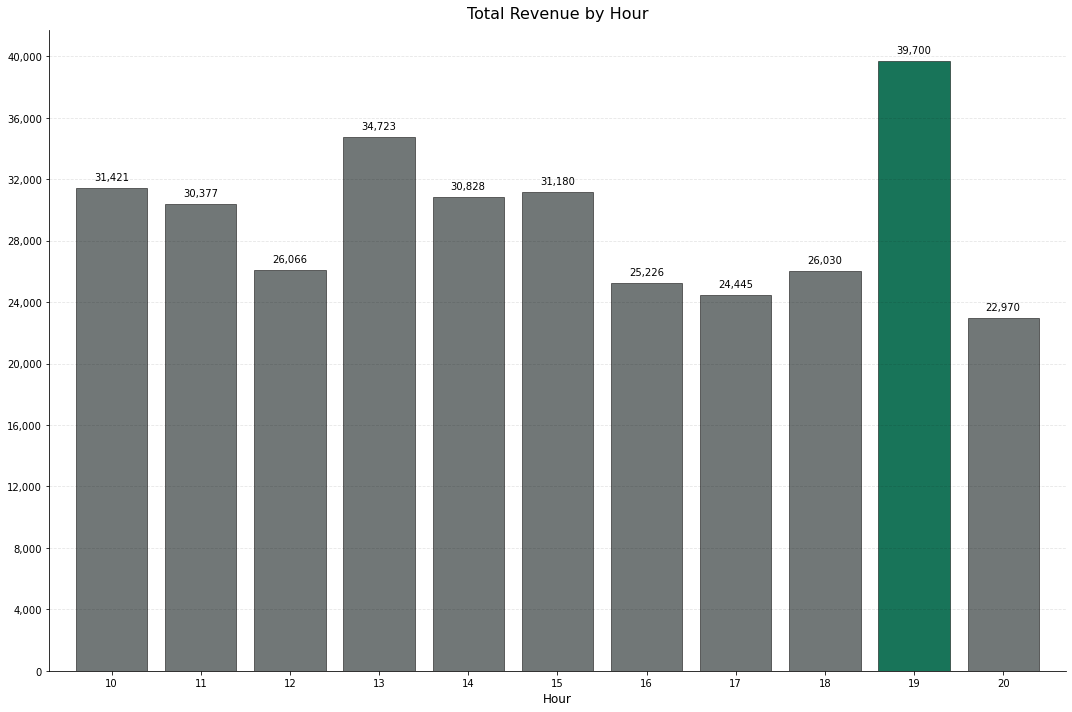

In [121]:
fig, ax = plt.subplots(figsize=(15, 10))

hours = hour_performance['Hour']
colors = ['#187459'] + ["#717777"] * (len(hour_performance) - 1)

bars = ax.bar(
    hours,
    hour_performance['total_revenue'],
    color=colors,
    edgecolor='black',
    linewidth=0.5)

# Title
ax.set_title('Total Revenue by Hour', fontsize=16, pad=12)
ax.set_xlabel('Hour', fontsize=12)

# Y-axis (clean and controlled)
max_val = hour_performance['total_revenue'].max()
ticks = np.arange(0, max_val * 1.10, 4000)
ax.set_yticks(ticks)
ax.set_yticklabels([f'{y:,.0f}' for y in ticks])

# Clean design
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.1, color='black')

# Values in bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 500,
            f'{height:,.0f}', ha='center', fontsize=10)

# Show all the hours
ax.set_xticks(hours[::1])
ax.set_xlim(min(hours)-0.7, max(hours)+0.7)

plt.tight_layout()
plt.show()

We can see that 7 PM is the time of day with the highest number of sales, with 113 transactions, as well as the highest total revenue, at 39,699.51. However, 2 PM has the highest average revenue per sale, at 371.43, despite having only 83 sales. It is followed by 7 PM, with an average revenue of 351.32 per sale.

Overall, we can conclude that 7 PM tends to be the best-performing time of day, as it generates both the highest number of sales and the highest total revenue.

**2.- Which day has the highest sales?**

We will also analyze which day of the week tends to generate the best sales, using the same metrics as before: total sales, total revenue, and average revenue per sale.

In [122]:
query = """
SELECT
    Day,
    COUNT(*) AS total_sales,
    ROUND(SUM(Sales), 2) AS total_revenue,
    ROUND(AVG(Sales), 2) AS average_revenue
FROM sales
GROUP BY Day
ORDER BY total_revenue DESC;
"""

day_performance = pd.read_sql(query, conn)

day_performance

,Day,total_sales,total_revenue,average_revenue
0,Saturday,164,56120.81,342.20
1,Tuesday,158,51482.25,325.84
2,Thursday,138,45349.25,328.62
3,Sunday,133,44457.89,334.27
4,Friday,139,43926.34,316.02
5,Wednesday,143,43731.14,305.81
6,Monday,125,37899.08,303.19


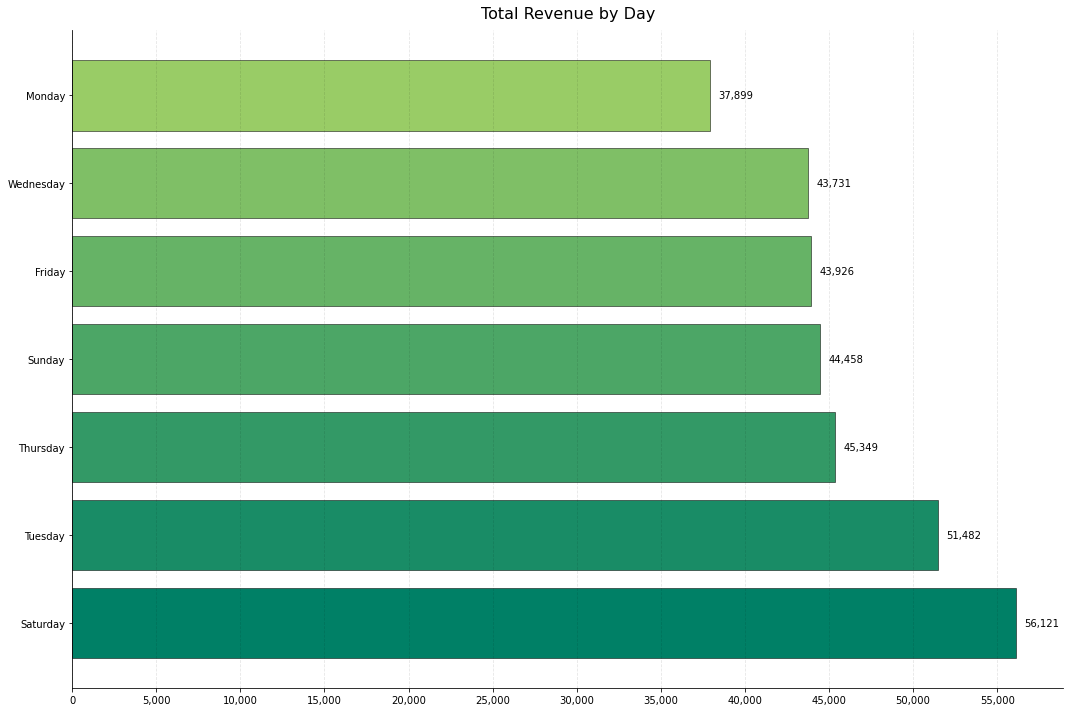

In [123]:
fig, ax = plt.subplots(figsize=(15, 10))

colors = cm.summer(np.linspace(0, 0.6, len(day_performance)))

bars = ax.barh(
    day_performance['Day'],
    day_performance['total_revenue'],
    color=colors,
    edgecolor='black',
    linewidth=0.5)

# Title
ax.set_title('Total Revenue by Day', fontsize=16, pad=12)

# X-axis (clean and controlled)
max_val = day_performance['total_revenue'].max()
ticks = np.arange(0, max_val * 1.05, 5000)
ax.set_xticks(ticks)
ax.set_xticklabels([f'{y:,.0f}' for y in ticks])

# Clean design
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.1, color='black')

# Values in bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 500, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Saturday stands out as the best-performing day of the week, achieving the strongest results across all three metrics: 164 total sales, total revenue of 56,120.81, and an average revenue of 342.20 per sale.

In contrast, Monday is the worst-performing day of the week, with the lowest figures across the metrics. This is particularly evident in its total revenue of 37,899.08, which is approximately 10,000 lower than Wednesday, the second-lowest day in terms of revenue.

**3.- Which day-hour combinations generate the highest and lowest sales?**

No analysis should overlook the combination of day and time, as demand can vary significantly depending on both variables. By analyzing these two factors together, we can gain a more detailed and accurate understanding of sales patterns and identify the time slots with the highest demand.

In [124]:
query = """
SELECT
    Day,
    Hour,
    COUNT(*) AS total_sales,
    ROUND(SUM(Sales), 2) AS total_revenue
FROM sales
GROUP BY Day, Hour
ORDER BY total_revenue DESC;
"""

day_hour_performance = pd.read_sql(query, conn)

day_hour_performance

,Day,Hour,total_sales,total_revenue
0,Tuesday,19,28,9198.67
1,Saturday,19,23,9117.38
2,Tuesday,15,14,7020.21
3,Thursday,10,18,6885.23
4,Friday,13,16,6824.31
...,...,...,...,...
72,Monday,20,10,2382.63
73,Sunday,16,6,2241.23
74,Friday,12,10,2159.24
75,Monday,14,6,2004.35


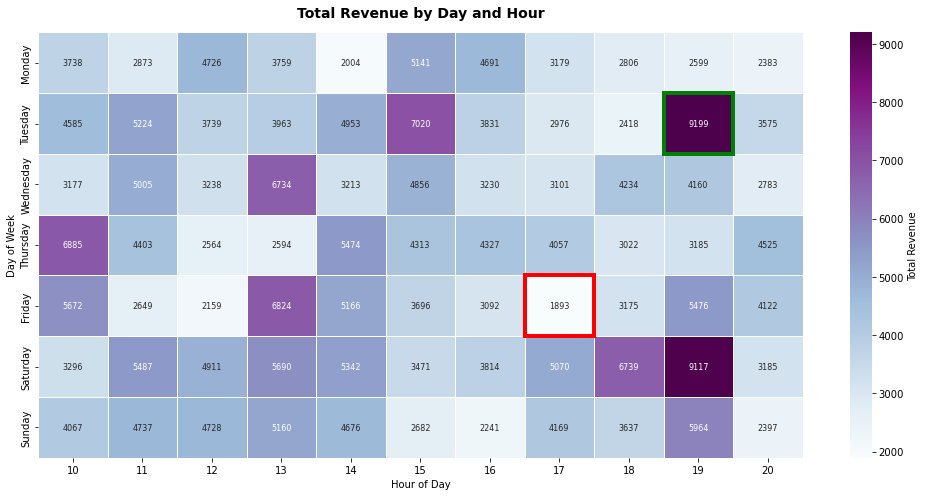

In [125]:
pivot = day_hour_performance.pivot(
    index="Day",
    columns="Hour",
    values="total_revenue")

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

pivot = pivot.reindex(day_order)

plt.figure(figsize=(14, 7))

ax = sns.heatmap(
    pivot,
    cmap="BuPu",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 8},
    linewidths=0.5,
    cbar_kws={"label": "Total Revenue"})

max_pos = np.unravel_index(
    np.nanargmax(pivot.values),
    pivot.shape)

min_pos = np.unravel_index(
    np.nanargmin(pivot.values),
    pivot.shape)

ax.add_patch(
    plt.Rectangle(
        (max_pos[1], max_pos[0]),
        1,1,
        fill=False,
        edgecolor="green",
        linewidth=4))

ax.add_patch(
    plt.Rectangle(
        (min_pos[1], min_pos[0]),
        1,1,
        fill=False,
        edgecolor="red",
        linewidth=4))

plt.title(
    "Total Revenue by Day and Hour",
    fontsize=14,
    fontweight="bold",
    pad=15)

plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

Tuesday at 7 PM stands out as the best-performing day-and-time combination overall, followed by Saturday at 7 PM. This is consistent with the previous analysis, which showed that 7 PM tends to be the strongest time of day and that Saturday and Tuesday are among the best-performing days of the week.

The heatmap also shows that Saturdays perform consistently well across most time slots, while Tuesdays achieve particularly strong results during key hours such as 7 PM, 3 PM, 11 AM, and 2 PM. In contrast, Mondays generally show weaker performance, with only a few notable results, mainly between 3 PM and 4 PM.

**4.- Which product generates the most revenue?**

Now that we know which days and times generate the highest revenue, we can move on to analyzing which product lines generate the highest profits.

In [126]:
query = """
SELECT
    "Product line" AS product_line,
    COUNT(*) AS total_sales,
    ROUND(SUM(Sales), 2) AS total_revenue,
    ROUND(AVG(Sales), 2) AS average_revenue
FROM sales
GROUP BY product_line
ORDER BY total_revenue DESC;
"""

product_line_performance = pd.read_sql(query, conn)

product_line_performance

,product_line,total_sales,total_revenue,average_revenue
0,Food and beverages,174,56144.84,322.67
1,Sports and travel,166,55122.83,332.07
2,Electronic accessories,170,54337.53,319.63
3,Fashion accessories,178,54305.90,305.09
4,Home and lifestyle,160,53861.91,336.64
5,Health and beauty,152,49193.74,323.64


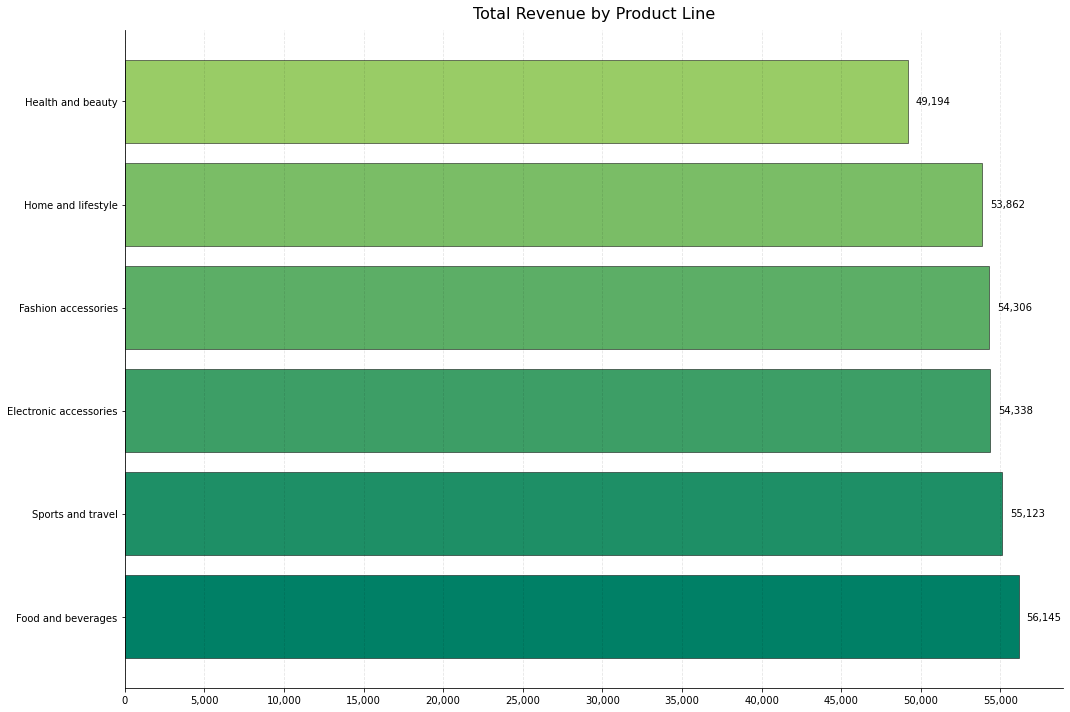

In [127]:
fig, ax = plt.subplots(figsize=(15, 10))

colors = cm.summer(np.linspace(0, 0.6, len(product_line_performance)))

bars = ax.barh(
    product_line_performance['product_line'],
    product_line_performance['total_revenue'],
    color=colors,
    edgecolor='black',
    linewidth=0.5)

# Title
ax.set_title('Total Revenue by Product Line', fontsize=16, pad=12)

# X-axis (clean and controlled)
max_val = product_line_performance['total_revenue'].max()
ticks = np.arange(0, max_val * 1.05, 5000)
ax.set_xticks(ticks)
ax.set_xticklabels([f'{y:,.0f}' for y in ticks])

# Clean design
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.1, color='black')

# Values in bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 500, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Several key insights can be observed from the results. The product line generating the highest total revenue is Food and Beverages. However, it does not have the highest average revenue per sale, ranking third-lowest among the product lines.

In contrast, Sports and Travel ranks second in total revenue and has the second-highest average revenue per sale, making it one of the strongest-performing product lines overall.

Finally, Fashion Accessories, despite having the highest number of sales, has the lowest average revenue per sale. Nevertheless, its total revenue is still higher than that of the two product lines with the fewest sales overall: Home and Lifestyle and Health and Beauty.


**5.- What time of day does each product line generate sales?**

We will take the analysis one step further by examining which products generate the highest sales and identifying the time slots in which they perform best.

In [128]:
query = """
SELECT
    Hour,
    "Product line" AS product_line,
    COUNT(*) AS total_sales,
    ROUND(SUM(Sales), 2) AS total_revenue,
    ROUND(AVG(Sales), 2) AS average_revenue
FROM sales
GROUP BY Hour, product_line
ORDER BY total_revenue DESC;
"""

product_performance = pd.read_sql(query, conn)

product_performance

,Hour,product_line,total_sales,total_revenue,average_revenue
0,19,Sports and travel,20,8918.25,445.91
1,13,Fashion accessories,19,8109.39,426.81
2,19,Food and beverages,26,7981.48,306.98
3,14,Health and beauty,19,7431.80,391.15
4,15,Food and beverages,21,7418.20,353.25
...,...,...,...,...,...
61,14,Home and lifestyle,9,2843.70,315.97
62,16,Health and beauty,10,2824.85,282.48
63,20,Fashion accessories,11,2309.69,209.97
64,17,Food and beverages,6,1421.34,236.89


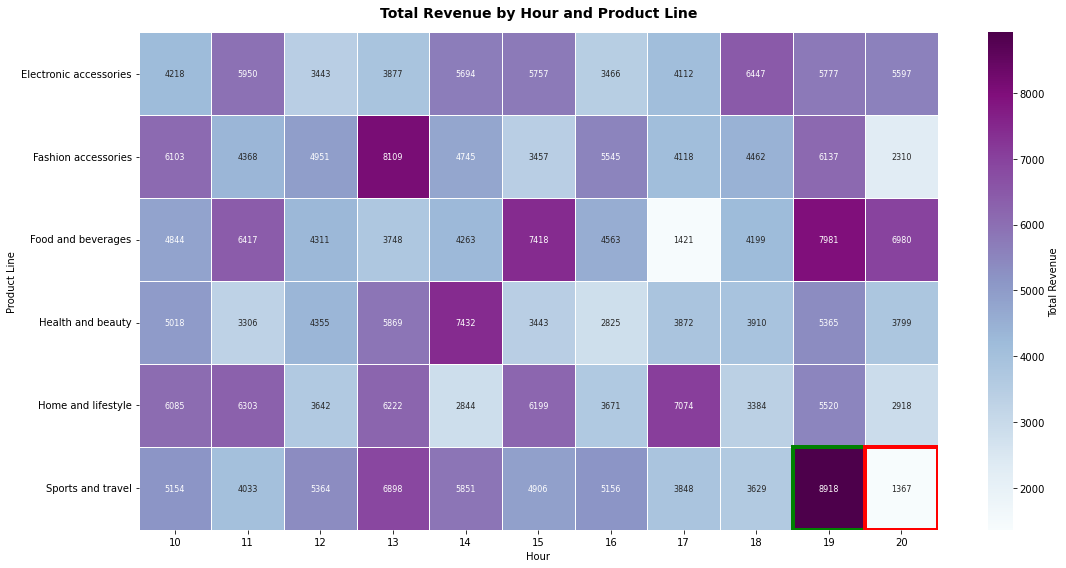

In [129]:
pivot = product_performance.pivot(
    index="product_line",
    columns="Hour",
    values="total_revenue")

plt.figure(figsize=(16, 8))

ax = sns.heatmap(
    pivot,
    cmap="BuPu",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 8},
    linewidths=0.5,
    cbar_kws={"label": "Total Revenue"})

max_pos = np.unravel_index(
    np.nanargmax(pivot.values),
    pivot.shape)

min_pos = np.unravel_index(
    np.nanargmin(pivot.values),
    pivot.shape)

ax.add_patch(
    plt.Rectangle(
        (max_pos[1], max_pos[0]),
        1,1,
        fill=False,
        edgecolor="green",
        linewidth=4))

ax.add_patch(
    plt.Rectangle(
        (min_pos[1], min_pos[0]),
        1,1,
        fill=False,
        edgecolor="red",
        linewidth=4))

plt.title(
    "Total Revenue by Hour and Product Line",
    fontsize=14,
    fontweight="bold",
    pad=15)

plt.xlabel("Hour")
plt.ylabel("Product Line")

plt.tight_layout()
plt.show()

We can see that Sports and Travel generates the highest revenue at 7 PM, while also recording its lowest revenue at 8 PM, the final hour of the day. Once again, 7 PM stands out as the strongest time slot on average across all product lines, reinforcing the trend identified in the previous analyses.

It is also worth noting that Food and Beverages, together with Sports and Travel, generates the highest levels of revenue across most time slots, making them the strongest-performing product lines throughout the day.

In contrast, Health and Beauty only clearly outperforms the other product lines at 2 PM, while also achieving slightly above-average results at 1 PM and 7 PM.